# 27. 외부 피처는 어느 품목에서 값을 하는가

## Overview

26번에서 **저장성 축이 아니라 품목 둘**이 출하량 효과를 끌고 있다는 게
드러났습니다.

| 품목 | 저장일수 | 기본 적중률 | +출하량 | 차이 |
|---|---|---|---|---|
| **파** | 7 | 59.77% | 64.37% | **+4.60%p** |
| **미나리** | 7 | 79.89% | 82.18% | **+2.30%p** |
| 나머지 7품목 | 10~165 | — | — | -1.44 ~ +0.86%p |

나머지 일곱은 전부 품목 노이즈(1.3~2.8%p) 안쪽이었습니다. 21번의 +2.97%p 도
25번의 +0.22%p 도 **이 둘이 있었나 없었나**로 설명됩니다.

**그런데 왜 이 둘인지는 모릅니다.** 이 문서가 그걸 좁힙니다.

## 무엇을 묻나

| 절 | 묻는 것 | 왜 |
|---|---|---|
| 2 | 폴드별로도 일관된가 | 26번은 7폴드 합산이라 **한 폴드가 끌었을 수 있습니다** |
| 3 | 출하량 중 **무엇이** 기여하나 | "출하량"이 아니라 그중 어느 정보인지 좁힙니다 |
| 4 | 출하량-가격 구조가 다른가 | 모델 밖에서 직접 보는 단서 |

## 미리 짚어둘 것

**미나리는 경계에 걸쳐 있습니다.** +2.30%p 인데 품목 노이즈가 1.3~2.8%p 라,
폴드로 쪼개면 더 흔들릴 수 있습니다. **일관성이 안 나오면 그것 자체가 답**
입니다: "효과가 있다"가 아니라 "한두 폴드가 만든 것"이 됩니다.

**파는 기본 적중률이 59.77% 로 9품목 중 최하위**입니다. 바닥이 낮으면 올릴
여지가 큽니다. 그래서 **절대 상승폭만 보면 안 되고**, 남은 오차 대비 얼마나
줄였는지도 같이 봐야 합니다.

## 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 효과가 폴드에 걸쳐 일관된다 | 7폴드 중 대부분에서 같은 부호 |
| **H2** | 특정 피처 묶음이 효과를 낸다 | 한 묶음만 넣어도 대부분 재현 |
| **H3** | 이 둘은 출하량-가격 관계가 다르다 | 상관·시차 구조가 나머지와 구별됨 |

## 목차

1. 준비
2. 폴드별 일관성
3. 어느 피처가 기여하나
4. 출하량과 가격의 관계
5. 정리

## 1. 준비

15·21·25·26번과 같은 피처·폴드·하이퍼파라미터입니다. **학습은 19품목 전부**
(19번에서 확정), 평가만 품목별로 바꿉니다.

비교 대상으로 **대조 품목 셋**을 같이 돌립니다: 26번에서 효과가 노이즈
이내였던 상추·배추·양파입니다. 파·미나리에서만 나오는 패턴인지 보려면
대조군이 필요합니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
all_items = sorted(df.item.unique())

주인공 = ["파", "미나리"]
대조 = ["상추", "배추", "양파"]      # 26번에서 효과가 노이즈 이내였던 품목
대상 = 주인공 + 대조

H, COV = 7, 0.4                      # 26번과 같은 운영 커버리지
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=all_items).codes

b["_logq"] = np.log1p(b.shipment_qty)
b["ship_ret1"] = b._logq - g("_logq").shift(1)
b["ship_dev20"] = b._logq - g("_logq").transform(
    lambda s: s.rolling(20, min_periods=7).mean())
b["ship_price"] = b.shipment_amt / b.shipment_qty.replace(0, np.nan)

# 출하량 피처를 뜻으로 묶는다
그룹 = {
    "물량": ["shipment_qty", "shipment_qty_w1ago", "shipment_qty_w2ago",
             "shipment_qty_w3ago", "shipment_qty_w4ago"],
    "금액": ["shipment_amt", "ship_price"],
    "시장 수": ["shipment_market_cnt"],
    "파생": ["ship_ret1", "ship_dev20"],
}
SHIP_ALL = [c for v in 그룹.values() for c in v]

feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)
BASE = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
        + [f"vol{w}" for w in (5, 20, 60)] + CAL
        + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
print(f"학습·평가 대상 {len(feat):,}행")
print(f"기본 {len(BASE)}피처 · 출하량 {len(SHIP_ALL)}피처")
for k, v in 그룹.items():
    print(f"  {k:6s} {len(v)}개: {v}")
print(f"\n주인공 {주인공} · 대조 {대조}")


def 돌리기(use, 평가품목, noise=None, seed=None):
    d, use = feat, list(use)
    if noise:
        d = feat.copy()
        rng = np.random.default_rng(seed)
        for j in range(noise):
            d[f"noise{j}"] = rng.normal(size=len(d))
            use.append(f"noise{j}")
    cat = [use.index(c) for c in ("item_code", "month", "dayofweek")]
    out = []
    for k, (s, e) in enumerate(FOLDS):
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = d[d.price_date < s - EMBARGO]
        te = d[(d.price_date >= s) & (d.price_date <= e) & (d.item.isin(평가품목))]
        if len(te) == 0:
            continue
        clf = HistGradientBoostingClassifier(
            categorical_features=sorted(cat), early_stopping=False,
            random_state=42, **PARAMS).fit(tr[use], tr.오름)
        t = te[["item", "price_date", "오름"]].copy()
        t["폴드"] = k
        t["오를확률"] = clf.predict_proba(te[use])[:, 1]
        out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


def 적중(r, cov=COV):
    q = r.확신도.quantile(1 - cov)
    s = r[r.확신도 >= q]
    return s.방향맞음.mean() * 100, len(s)

학습·평가 대상 23,945행
기본 21피처 · 출하량 10피처
  물량     5개: ['shipment_qty', 'shipment_qty_w1ago', 'shipment_qty_w2ago', 'shipment_qty_w3ago', 'shipment_qty_w4ago']
  금액     2개: ['shipment_amt', 'ship_price']
  시장 수   1개: ['shipment_market_cnt']
  파생     2개: ['ship_ret1', 'ship_dev20']

주인공 ['파', '미나리'] · 대조 ['상추', '배추', '양파']


## 2. 폴드별 일관성

26번은 7폴드를 합쳐 하나의 숫자를 냈습니다. **한 폴드가 끌었을 수 있습니다.**

폴드마다 따로 재서 부호가 일관되는지 봅니다. **커버리지는 폴드 안에서 다시
맞춥니다** — 전체 기준으로 자르면 폴드마다 남는 날 수가 달라져 비교가
흐려집니다.

In [2]:
t0 = time.time()
예측 = {}
for it in 대상:
    예측[(it, "기본")] = 돌리기(BASE, [it])
    예측[(it, "출하량")] = 돌리기(BASE + SHIP_ALL, [it])

rows = []
for it in 대상:
    a, s_ = 예측[(it, "기본")], 예측[(it, "출하량")]
    for k in sorted(a.폴드.unique()):
        af, sf = a[a.폴드 == k], s_[s_.폴드 == k]
        if len(af) < 30:
            continue
        qa = af.확신도.quantile(1 - COV)
        qs = sf.확신도.quantile(1 - COV)
        기본 = af[af.확신도 >= qa].방향맞음.mean() * 100
        출하 = sf[sf.확신도 >= qs].방향맞음.mean() * 100
        rows.append({"item": it, "폴드": FOLDS[k][0][:7], "기본 %": 기본,
                     "출하량 %": 출하, "차이 %p": 출하 - 기본,
                     "남는 날": int(len(af) * COV)})
폴드별 = pd.DataFrame(rows)
피벗 = 폴드별.pivot(index="폴드", columns="item", values="차이 %p")[대상]
display(피벗.round(2))

요약 = pd.DataFrame({
    "폴드 평균 %p": 폴드별.groupby("item")["차이 %p"].mean(),
    "폴드 표준편차": 폴드별.groupby("item")["차이 %p"].std(),
    "양수 폴드": 폴드별.groupby("item")["차이 %p"].apply(
        lambda s: f"{(s > 0).sum()}/{len(s)}"),
}).loc[대상]
display(요약.round(2))
print(f"({time.time()-t0:.0f}초)")
print("'양수 폴드' 가 7/7 에 가까우면 일관된 것이고, 4/7 근처면 우연입니다.")

item,파,미나리,상추,배추,양파
폴드,,,,,
2023-01,-2.04,0.00,2.04,6.12,-3.10
2023-07,6.12,14.29,-2.04,-2.04,-4.08
2024-01,10.20,2.04,0.00,10.20,-2.04
2024-07,2.04,0.00,-0.49,2.04,6.12
2025-01,12.77,-4.26,-2.13,-8.51,-6.38
2025-07,-4.00,0.00,0.00,-4.00,-2.00
2026-01,10.71,5.36,0.00,-1.79,1.79


,폴드 평균 %p,폴드 표준편차,양수 폴드
item,,,
파,5.12,6.59,5/7
미나리,2.49,5.94,3/7
상추,-0.37,1.42,1/7
배추,0.29,6.34,3/7
양파,-1.39,4.13,2/7


(122초)
'양수 폴드' 가 7/7 에 가까우면 일관된 것이고, 4/7 근처면 우연입니다.


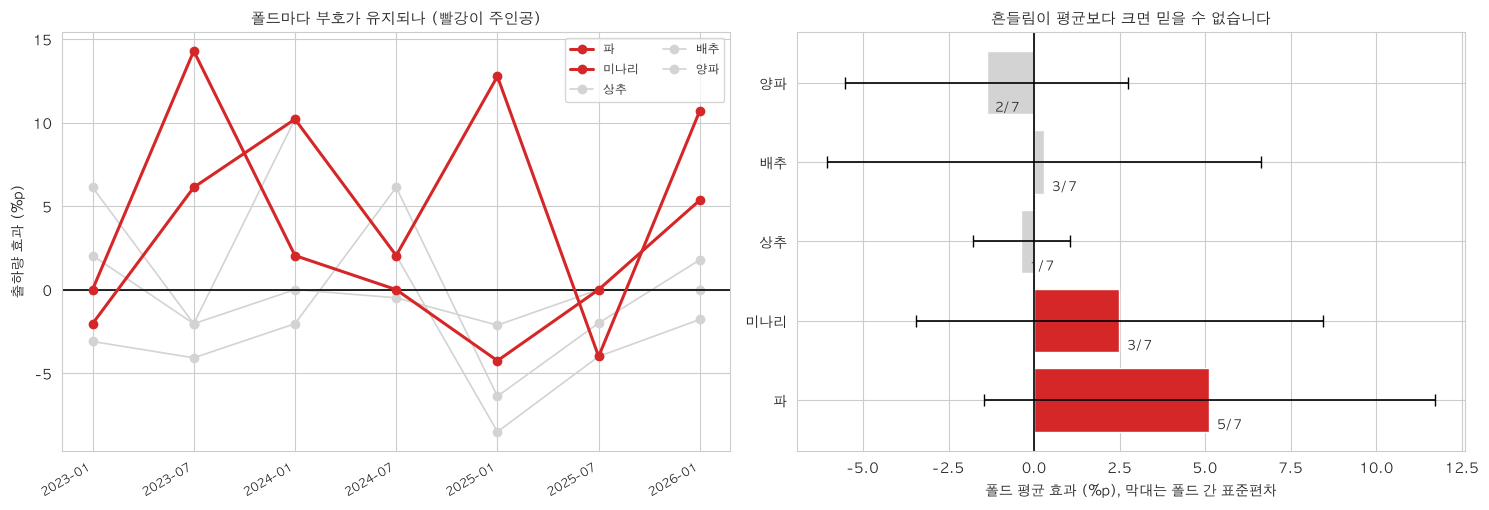

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

ax = axes[0]
x = np.arange(len(피벗))
for it in 대상:
    색 = "tab:red" if it in 주인공 else "lightgray"
    lw = 2.2 if it in 주인공 else 1.2
    ax.plot(x, 피벗[it], "o-", ms=6, color=색, lw=lw, label=it,
            zorder=3 if it in 주인공 else 1)
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(피벗.index, rotation=30, ha="right", fontsize=8.5)
ax.set_ylabel("출하량 효과 (%p)")
ax.set_title("폴드마다 부호가 유지되나 (빨강이 주인공)", fontsize=11)
ax.legend(fontsize=8.5, ncol=2)

ax = axes[1]
색들 = ["tab:red" if it in 주인공 else "lightgray" for it in 요약.index]
ax.barh(요약.index, 요약["폴드 평균 %p"], color=색들,
        xerr=요약["폴드 표준편차"], capsize=4, error_kw={"lw": 1.2})
ax.axvline(0, color="black", lw=1.2)
for i, n in enumerate(요약["양수 폴드"]):
    ax.text(요약["폴드 평균 %p"].iloc[i], i - 0.32, f"  {n}", fontsize=9,
            va="center")
ax.set_xlabel("폴드 평균 효과 (%p), 막대는 폴드 간 표준편차")
ax.set_title("흔들림이 평균보다 크면 믿을 수 없습니다", fontsize=11)

plt.tight_layout()
plt.show()

## 3. 어느 피처가 기여하나

출하량 10개를 **뜻으로 네 묶음**으로 갈라 하나씩만 넣어 봅니다. 한 묶음만으로
효과가 재현되면 "출하량"이 아니라 **그 정보**가 답입니다.

| 묶음 | 피처 | 무엇을 담나 |
|---|---|---|
| 물량 | `shipment_qty` + `w1~w4ago` | 절대 반입량과 4주 이력 |
| 금액 | `shipment_amt` · `ship_price` | 거래대금과 단가 |
| 시장 수 | `shipment_market_cnt` | 몇 개 시장에 들어왔나 |
| 파생 | `ship_ret1` · `ship_dev20` | 전일 대비·20일 평균 대비 |

**`ship_price` 를 주의해서 봐야 합니다.** 출하 금액 ÷ 물량이라 **사실상 가격**
입니다. 이게 기여한다면 "출하량 정보"가 아니라 **또 다른 가격 계열**을 넣은
셈이라, 해석이 달라집니다.

In [4]:
t0 = time.time()
rows = []
for it in 대상:
    기본, n = 적중(예측[(it, "기본")])
    전부, _ = 적중(예측[(it, "출하량")])
    row = {"item": it, "기본 %": 기본, "전부 %": 전부, "전부 차이": 전부 - 기본}
    for 이름, cols in 그룹.items():
        r = 돌리기(BASE + cols, [it])
        acc, _ = 적중(r)
        row[f"{이름} 차이"] = acc - 기본
    rows.append(row)
기여 = pd.DataFrame(rows).set_index("item").loc[대상]
display(기여.round(2))
print(f"({time.time()-t0:.0f}초)")
print("한 묶음만으로 '전부 차이' 에 가까우면 그 묶음이 효과의 출처입니다.")

,기본 %,전부 %,전부 차이,물량 차이,금액 차이,시장 수 차이,파생 차이
item,,,,,,,
파,59.77,64.37,4.60,1.72,-0.86,-0.57,0.29
미나리,79.89,82.18,2.30,2.30,0.57,0.29,0.00
상추,80.23,80.86,0.63,0.86,-0.57,0.00,0.57
배추,70.40,70.69,0.29,0.29,2.01,2.01,0.29
양파,64.74,64.45,-0.29,1.45,1.73,0.87,0.00


(249초)
한 묶음만으로 '전부 차이' 에 가까우면 그 묶음이 효과의 출처입니다.


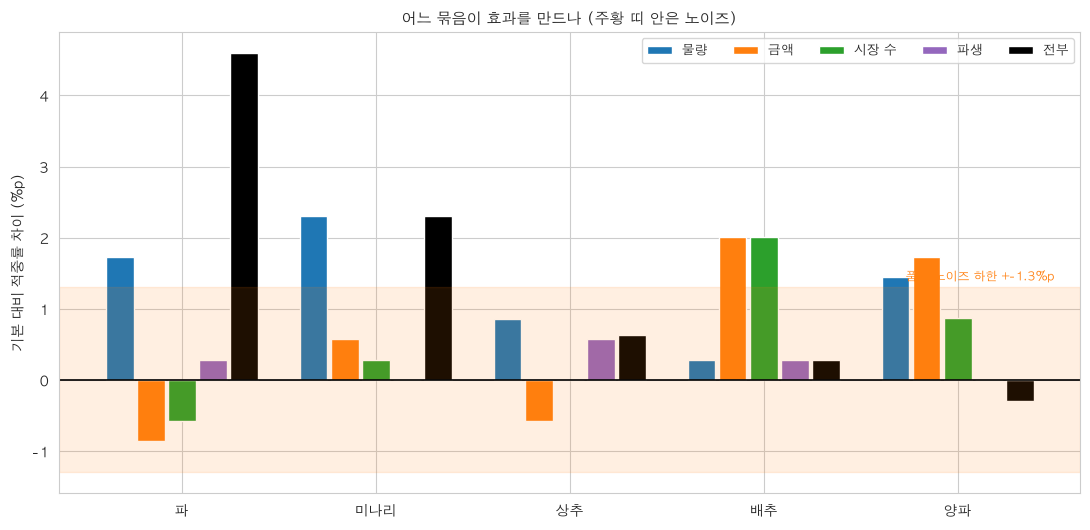

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.4))
묶음들 = list(그룹) + ["전부"]
x = np.arange(len(대상))
w = 0.16
색상 = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "black"]
for i, (이름, c) in enumerate(zip(묶음들, 색상)):
    ax.bar(x + (i - 2) * w, 기여[f"{이름} 차이"], width=w * 0.9, color=c,
           label=이름)
ax.axhline(0, color="black", lw=1.2)
ax.axhspan(-1.3, 1.3, color="tab:orange", alpha=0.12)
ax.text(len(대상) - 0.5, 1.4, "품목 노이즈 하한 +-1.3%p", fontsize=8.5,
        color="tab:orange", ha="right")
ax.set_xticks(x)
ax.set_xticklabels(대상, fontsize=10)
ax.set_ylabel("기본 대비 적중률 차이 (%p)")
ax.set_title("어느 묶음이 효과를 만드나 (주황 띠 안은 노이즈)", fontsize=11)
ax.legend(fontsize=9, ncol=5)
plt.tight_layout()
plt.show()

## 4. 출하량과 가격의 관계

모델 밖에서 직접 봅니다. **파·미나리는 출하량과 가격의 관계가 나머지와
다른가?**

두 가지를 잽니다.

- **동시점 상관**: 오늘 물량이 많으면 오늘 가격이 싼가 (수급의 기본)
- **선행 상관**: 오늘 물량이 **7거래일 뒤** 가격 변화를 예고하는가

**선행 상관이 예측에 쓰이는 정보입니다.** 동시점만 강하면 이미 가격에 반영된
것이라 새로 알려주는 게 없습니다.

In [6]:
채움 = df.groupby("item").shipment_qty.apply(lambda s: s.notna().mean())
있는품목 = sorted(채움.index[채움 > 0.5])
rows = []
for it in 있는품목:
    s = b[b.item == it].dropna(subset=["_logq", "_logp", "y"])
    if len(s) < 300:
        continue
    rows.append({
        "item": it,
        "동시점 상관": s._logq.corr(s._logp, method="spearman"),
        "물량변화 vs 미래가격변화": s.ship_ret1.corr(s.y, method="spearman"),
        "물량편차 vs 미래가격변화": s.ship_dev20.corr(s.y, method="spearman"),
        "관측": len(s),
        "주인공": it in 주인공,
    })
관계 = pd.DataFrame(rows).set_index("item")
관계["선행 상관 크기"] = 관계[["물량변화 vs 미래가격변화",
                              "물량편차 vs 미래가격변화"]].abs().max(axis=1)
display(관계.sort_values("선행 상관 크기", ascending=False).round(3))
print("'선행 상관' 이 예측에 쓰이는 정보입니다. 동시점만 크면 이미 가격에 반영된 것입니다.")

,동시점 상관,물량변화 vs 미래가격변화,물량편차 vs 미래가격변화,관측,주인공,선행 상관 크기
item,,,,,,
얼갈이배추,-0.189,-0.063,-0.173,1365,False,0.173
생강,-0.095,-0.019,-0.159,1356,False,0.159
풋고추,-0.117,-0.072,-0.130,1365,False,0.130
미나리,-0.112,-0.032,-0.116,1354,True,0.116
감자,0.059,-0.015,-0.115,1358,False,0.115
상추,-0.353,-0.088,-0.096,1365,False,0.096
양파,-0.022,-0.016,-0.062,1345,False,0.062
배추,0.170,-0.030,0.007,1356,False,0.030
파,0.143,-0.021,0.006,1352,True,0.021


'선행 상관' 이 예측에 쓰이는 정보입니다. 동시점만 크면 이미 가격에 반영된 것입니다.


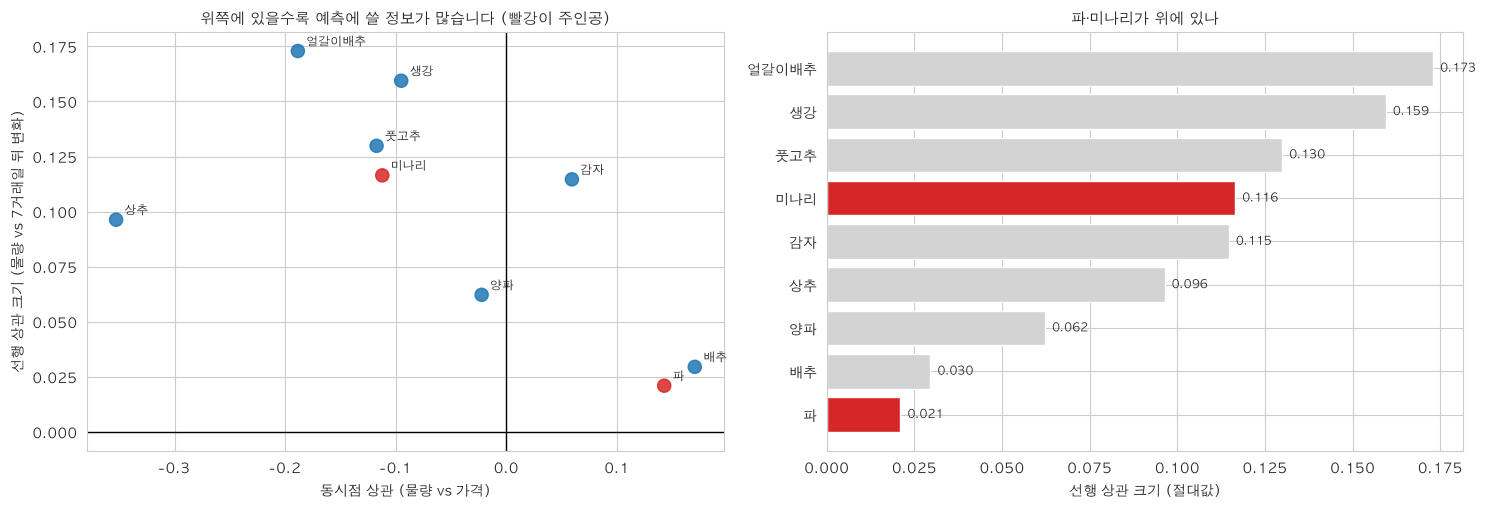

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

ax = axes[0]
색들 = ["tab:red" if v else "tab:blue" for v in 관계.주인공]
ax.scatter(관계["동시점 상관"], 관계["선행 상관 크기"], s=90, c=색들, alpha=0.85)
for it, row in 관계.iterrows():
    ax.annotate(it, (row["동시점 상관"], row["선행 상관 크기"]), fontsize=8.5,
                xytext=(6, 4), textcoords="offset points")
ax.axhline(0, color="black", lw=1)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("동시점 상관 (물량 vs 가격)")
ax.set_ylabel("선행 상관 크기 (물량 vs 7거래일 뒤 변화)")
ax.set_title("위쪽에 있을수록 예측에 쓸 정보가 많습니다 (빨강이 주인공)",
             fontsize=11)

ax = axes[1]
s = 관계.sort_values("선행 상관 크기")
색들 = ["tab:red" if v else "lightgray" for v in s.주인공]
ax.barh(s.index, s["선행 상관 크기"], color=색들)
for i, v in enumerate(s["선행 상관 크기"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8.5)
ax.set_xlabel("선행 상관 크기 (절대값)")
ax.set_title("파·미나리가 위에 있나", fontsize=11)

plt.tight_layout()
plt.show()

## 5. 정리

### 한 줄 요약

**파·미나리의 효과는 견고하지 않습니다.** 폴드로 쪼개면 흔들림이 평균보다
크고, 피처 묶음으로 갈라도 출처가 안 잡히며, 출하량-가격 관계로도 설명되지
않습니다. **26번의 "원인은 품목 둘" 이라는 결론을 정정해야 합니다.**

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 효과가 폴드에 걸쳐 일관된다 | 파 5/7·미나리 **3/7**, 표준편차가 평균보다 큼 | **반증됨** |
| **H2** | 특정 피처 묶음이 효과를 낸다 | 부분합이 전체를 재현 못 하고, **대조군에서도 같은 크기가 나옴** | **반증됨** |
| **H3** | 출하량-가격 관계가 다르다 | 파의 선행 상관이 **9품목 중 꼴찌** | **반증됨** |

### 폴드로 쪼개니 무너집니다

| 폴드 | 파 | 미나리 | 상추 | 배추 | 양파 |
|---|---|---|---|---|---|
| 2023-01 | -2.04 | 0.00 | 2.04 | 6.12 | -3.10 |
| 2023-07 | 6.12 | **14.29** | -2.04 | -2.04 | -4.08 |
| 2024-01 | 10.20 | 2.04 | 0.00 | 10.20 | -2.04 |
| 2024-07 | 2.04 | 0.00 | -0.49 | 2.04 | 6.12 |
| 2025-01 | 12.77 | -4.26 | -2.13 | -8.51 | -6.38 |
| 2025-07 | -4.00 | 0.00 | 0.00 | -4.00 | -2.00 |
| 2026-01 | 10.71 | 5.36 | 0.00 | -1.79 | 1.79 |

| 품목 | 폴드 평균 | 폴드 표준편차 | 양수 폴드 |
|---|---|---|---|
| 파 | +5.12%p | **6.59** | 5/7 |
| **미나리** | +2.49%p | **5.94** | **3/7** |
| 상추 | -0.37%p | 1.42 | 1/7 |
| 배추 | +0.29%p | 6.34 | 3/7 |
| 양파 | -1.39%p | 4.13 | 2/7 |

**미나리는 3/7 입니다.** 동전 던지기와 구별되지 않고, 26번의 +2.30%p 는
**2023-07 한 폴드의 +14.29%p** 가 만든 값입니다.

**파는 5/7 로 낫지만 표준편차가 6.59 로 평균(5.12)보다 큽니다.** 2025-01 에
+12.77 이었다가 2025-07 에 -4.00 입니다. **대조군인 배추도 표준편차 6.34** 라,
이 흔들림은 파의 특성이 아니라 **품목 하나로 쪼갰을 때의 일반적 잡음**입니다.

### 피처 묶음으로도 출처가 안 잡힙니다

| 품목 | 전부 | 물량 | 금액 | 시장 수 | 파생 |
|---|---|---|---|---|---|
| 파 | **+4.60** | +1.72 | -0.86 | -0.57 | +0.29 |
| 미나리 | +2.30 | +2.30 | +0.57 | +0.29 | 0.00 |
| 상추 | +0.63 | +0.86 | -0.57 | 0.00 | +0.57 |
| **배추** | **+0.29** | +0.29 | **+2.01** | **+2.01** | +0.29 |
| **양파** | **-0.29** | +1.45 | +1.73 | +0.87 | 0.00 |

**대조군이 판정을 내려줍니다.** 배추는 전체가 +0.29 인데 금액·시장 수 묶음이
각각 **+2.01** 이고, 양파는 전체가 -0.29 인데 물량 +1.45·금액 +1.73 입니다.
**부분이 전체보다 큰 건 정보가 아니라 잡음입니다.**

같은 잣대로 보면 파의 물량 +1.72 도 특별하지 않습니다. 그리고 파는 **전체
+4.60 을 어느 묶음도 재현하지 못합니다**(최대 +1.72). 상호작용일 수도 있지만,
대조군에서 같은 크기의 잡음이 나오는 이상 그렇게 읽을 근거가 없습니다.

**`ship_price` 걱정은 기우였습니다.** 금액 묶음이 파에서 -0.86 이라, 가격
계열이 몰래 기여한 흔적은 없습니다.

### 출하량-가격 관계로도 설명이 안 됩니다

| 품목 | 동시점 상관 | 선행 상관 크기 | 모델 효과 |
|---|---|---|---|
| 얼갈이배추 | -0.189 | **0.173** | +0.86%p |
| 생강 | -0.095 | 0.159 | -1.44%p |
| 풋고추 | -0.117 | 0.130 | -0.57%p |
| 미나리 | -0.112 | 0.116 | +2.30%p |
| 상추 | -0.353 | 0.096 | +0.63%p |
| 배추 | +0.170 | 0.030 | +0.29%p |
| **파** | +0.143 | **0.021** | **+4.60%p** |

**파는 선행 상관이 9품목 중 꼴찌인데 모델 효과는 1위입니다.** 정반대입니다.
1위인 얼갈이배추(0.173)는 모델 효과가 +0.86%p 로 작습니다. **두 지표에
아무 관계가 없습니다.**

선행 상관이 전부 0.2 미만인 것도 눈여겨볼 대목입니다. 출하량이 7거래일 뒤
가격 변화를 예고하는 정도가 **어느 품목에서도 약합니다.**

### 26번을 정정해야 합니다

26번 결론에 이렇게 적었습니다.

> **진짜 원인은 품목 둘입니다** … 파와 미나리 둘만 품목 노이즈를 넘습니다

**그 판정이 지나쳤습니다.** 26번은 7폴드를 합쳐 한 번 잰 값이었고, 쪼개보니
미나리는 3/7 이고 파도 흔들림이 평균보다 큽니다. 26번 자신이 "품목별 노이즈는
안 쟀으니 상한으로 읽으세요" 라고 적어뒀는데, **정리 절에서 그 경고를 스스로
어겼습니다.**

### 그럼 21·26번의 그룹 결과는 뭐였나

**그룹 수준 결과는 부정되지 않습니다.**

| 노트북 | 대상 | 커버리지 40% | 노이즈 넘김 |
|---|---|---|---|
| 21 | 6품목 | +2.97%p | 4/7 구간 |
| 26 단기 | 6품목 | +1.87%p | **6/6 구간** |

품목을 묶으면 표본이 6배가 되어 노이즈가 좁아지고, 거기서는 효과가 노이즈를
넘습니다. **묶으면 보이고 쪼개면 안 보이는 상태**입니다.

**이건 모순이 아니라 표본 문제입니다.** 그룹 효과가 실재하되 **어느 품목에서
오는지는 이 데이터로 못 가릅니다.** 품목당 관측일이 871일(폴드당 124일)이라
품목 단위 판정에는 부족합니다.

### 한계

- **품목당 폴드 표본이 얇습니다.** 커버리지 40% 를 적용하면 폴드당 남는 날이
  50일 안팎이라, 한 번 맞고 틀리는 게 2%p 를 움직입니다. 폴드별 값이 0.00 이나
  ±2.04 같은 값에 몰리는 게 그 증거입니다.
- **대조군을 셋만 썼습니다.** 상추·배추·양파인데, 아홉 품목 전부로 하면
  잡음 분포를 더 정확히 볼 수 있습니다.
- **선행 상관은 선형(순위) 관계만 봅니다.** 모델은 비선형·상호작용을 쓰므로,
  상관이 낮다고 정보가 없다는 뜻은 아닙니다. **다만 설명이 안 된다는 건
  사실입니다.**

### 다음

1. **26번에 정정 주의를 답니다**(지침 12절: 앞 결론이 뒤집히면 지우지 않고
   주의를 단다).
2. **품목 단위 귀속은 여기서 닫습니다.** 표본이 부족해 더 파도 답이 안 나옵니다.
   "어느 품목이 값을 할지"를 미리 고르는 방법은 **없습니다.**
3. **그룹 수준 사실만 남깁니다**: 출하량은 여러 품목을 묶었을 때 운영 지점에서
   1~3%p 를 올립니다. 어느 품목에서 오는지는 모릅니다.